## Импорт библиотек

In [31]:
import warnings
warnings.filterwarnings('ignore')

import os
import gc
import json
import time
import psutil
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


## Динамика точности модели в зависимости от количества признаков при различных пороговых значениях RFECV

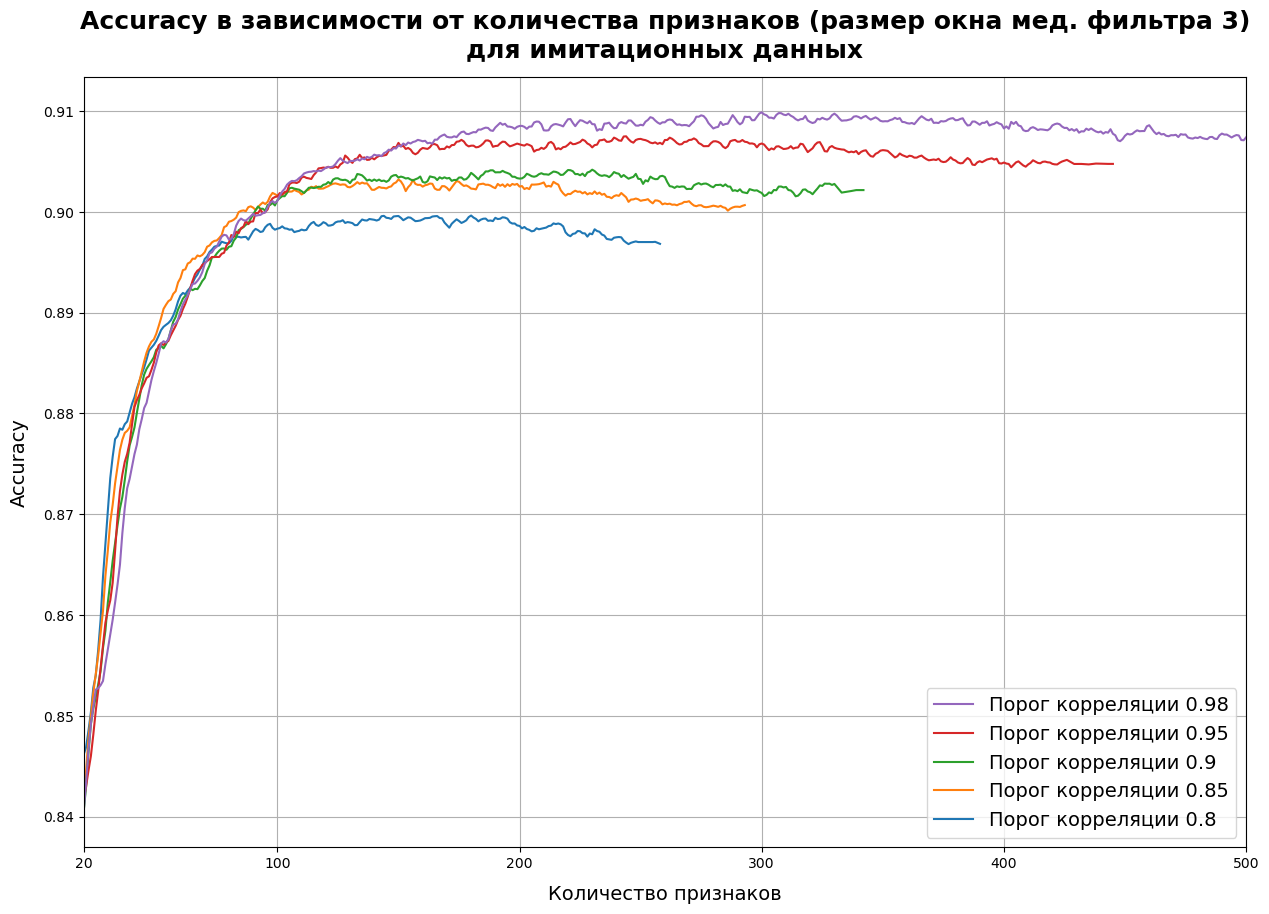

In [48]:
thresholds = [0.8, 0.85, 0.9, 0.95, 0.98, 1]

def moving_average(data, median_window_size):
    
    if median_window_size % 2 == 0:
        raise ValueError("Размер окна должен быть нечетным")
    
    data = np.array(data)
    half_window = median_window_size // 2
    
    # Дополнение массива
    padded_data = np.pad(data, (half_window, half_window), mode='edge')

    # Ядро для свертки
    kernel = np.ones(median_window_size) / median_window_size
    
    # Применение свертки
    result = np.convolve(padded_data, kernel, mode='valid')
    
    return result

# Параметры
a = 20                  # a э [1; inf]
b = 500                  # b э [a+1; inf]
median_window_size = 3  # Размер окна для сглаживания (нечетный)

rfecv_results_dir = 'DATA/rfecv_results'

json_file_names = [name for name in os.listdir(rfecv_results_dir) if "json" in name]
rfecv_results_list = []

for name in json_file_names: 
    with open(rf'{rfecv_results_dir}\{name}', 'r', encoding='utf-8') as file:
        rfecv_results_list.append(json.load(file))
        
a = max(1, a)

plt.figure(figsize=(15, 10))

for res, threshold in zip(rfecv_results_list, thresholds):
    new_a = min(len(res['mean_test_score']), a)
    new_b = min(len(res['mean_test_score']), b)
    
    smoothed_res = moving_average(res['mean_test_score'][new_a-1:new_b], median_window_size)
    x_range = range(new_a, new_b+1)
    
    plt.plot(x_range, 
             smoothed_res,
             label=f'Порог корреляции {float(threshold)}')
    
plt.xlim(x_range.start, x_range.stop - 1)
plt.xticks(np.arange(new_a, new_b+1, 60))  # шаг 50
plt.xticks([20, 100, 200, 300, 400, 500])  # шаг 50
plt.grid()
plt.xlabel("Количество признаков",
           fontsize=14, 
           fontweight='medium', 
           labelpad=10)

plt.ylabel("Accuracy",
           fontsize=14, 
           fontweight='medium', 
           labelpad=10)

plt.title(f"Accuracy в зависимости от количества признаков (размер окна мед. фильтра {median_window_size})\nдля имитационных данных", 
          fontweight='demibold', 
          fontsize=18, 
          pad=15)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc='lower right', fontsize=14)
plt.savefig('APPLICATIONS/Accuracy в зависимости от количества признаков.png', dpi=400, bbox_inches='tight')

plt.show()


**Оптимальным является порог 0.98 при количестве признаков 100-200**

## Более взвешенная оценка точности модели в выбранном диапазоне количества признаков

In [21]:
# Загрузка результатов RFECV
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

num_of_features_start = 40
num_of_features_end = 70
n_iter = 100

# Загрузка данных
features_df = pd.read_csv('DATA/features/REAL_features_ws32_overlap75.csv')

# Разделение на признаки и целевую переменную
X = features_df.drop(columns=["Класс"])
y = features_df["Класс"].values

# Словарь для хранения средней точности для каждого числа признаков
results = {}

for num_of_features in range(num_of_features_start, num_of_features_end + 1):
    features = file["optimal_features"][:num_of_features]
    new_X = X[features]
    acc = 0

    for i in range(n_iter):
        # Разделение на обучающую и тестовую выборки
        X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, stratify=y, random_state=i)

        # Обучение XGBoost
        model = XGBClassifier(random_state=i, device="cuda", tree_method="hist", n_jobs=-1)
        model.fit(X_train, y_train)

        # Предсказание
        y_pred = model.predict(X_test)
        acc += accuracy_score(y_test, y_pred) * 100

    mean_acc = acc / n_iter
    results[num_of_features] = mean_acc
    print(f"Features: {num_of_features}, Mean Accuracy: {mean_acc:.2f}%")

# Создание DataFrame с результатами
acc_df = pd.DataFrame.from_dict(results, orient='index', columns=['Mean_Acc'])
acc_df.index.name = 'Num_Features'
acc_df = acc_df.sort_values('Mean_Acc', ascending=False)

print("\n", acc_df)


Features: 45, Mean Accuracy: 96.63%
Features: 46, Mean Accuracy: 96.64%
Features: 47, Mean Accuracy: 96.64%
               Mean_Acc
Num_Features           
46            96.641226
47            96.640325
45            96.627103


**Выбрано оптимальное количество признаков 50**

## Предпросмотр выбранных признаков

In [22]:
with open("DATA/related_info/sorted_feature_extraction_time.json", 'r') as f:
    file = json.load(f)


table_data = defaultdict(lambda: defaultdict(list))

signals = ['gx', 'gy', 'gz', 'ax', 'ay', 'az', 'mag_a', 'mag_g']

counter = 0
for feature, _ in file.items():
    parts = feature.split('_')
    if counter >= 300:
        break
    if (parts[0] in signals or f"{parts[0]}_{parts[1]}" in signals) and ('TD' in parts):
        signal_type = parts[0]
        if signal_type == 'mag':
            signal_type = f"{signal_type}_{parts[1]}"
            
        if '_dif_dif_' in feature:
            diff_level = '2nd diff'
        elif '_dif_' in feature:
            diff_level = '1st diff'
        else:
            diff_level = 'original'
        
        table_data[signal_type][diff_level].append(parts[-1])
        counter += 1

print(counter)

diff_levels = ['original', '1st diff', '2nd diff']


for signal in signals:
    print(f"{signal.upper()}:")
    
    for diff_level in diff_levels:
        stats = sorted(set(table_data[signal][diff_level]))
        print(f"  {diff_level}: {'/'.join(stats)}") if stats else print(f"  {diff_level}:")
    print()


300
GX:
  original: CumsumFinal/CumsumMax/CumsumMin/CumsumRange/Integral/IntegralSq/L1/Max/Mean/Min/Ptp/RMS/SumSq
  1st diff: CumsumFinal/CumsumMax/CumsumMin/CumsumRange/Integral/IntegralSq/L1/Max/Mean/Min/Ptp/RMS/SumSq
  2nd diff: CumsumFinal/CumsumMax/CumsumMin/CumsumRange/Integral/IntegralSq/L1/Max/Mean/Min/Ptp/RMS/SumSq

GY:
  original: CumsumFinal/CumsumMax/CumsumMin/CumsumRange/Integral/IntegralSq/L1/Max/Mean/Min/Ptp/RMS/SumSq
  1st diff: CumsumFinal/CumsumMax/CumsumMin/CumsumRange/Integral/IntegralSq/L1/Max/Mean/Min/Ptp/RMS/SumSq
  2nd diff: CumsumFinal/CumsumMax/CumsumMin/CumsumRange/Integral/IntegralSq/L1/Max/Mean/Min/Ptp/RMS/SumSq

GZ:
  original: CumsumFinal/CumsumMax/CumsumMin/CumsumRange/Integral/IntegralSq/L1/Max/Mean/Min/Ptp/RMS/SumSq
  1st diff: CumsumFinal/CumsumMax/CumsumMin/CumsumRange/Integral/IntegralSq/L1/Max/Mean/Min/Ptp/RMS/SumSq
  2nd diff: CumsumFinal/CumsumMax/CumsumMin/CumsumRange/Integral/IntegralSq/L1/Max/Mean/Min/Ptp/RMS/SumSq

AX:
  original: CumsumFinal

In [25]:
# Список для хранения названий всех признаков
cols = []

# Базовые статистические признаки
common_cols = ["CumsumFinal", "CumsumMax", "CumsumMin", 
               "CumsumRange", "Integral", "IntegralSq", 
               "L1", "Max", "Mean", "Min", "Ptp", "RMS","SumSq"]

# Признаки для каждой оси отдельно
for channel in ["gx", "gy", "gz", "ax", "ay", "az", "mag_g", "mag_a"]:
    for dif in ["", "dif_", "dif_dif_"]:
        for col_name in common_cols:
            cols.append(f"{channel}_TD_{dif}{col_name}")

# Сохранение в JSON файл
with open('DATA/real_time/selected_features.json', 'w', encoding='utf-8') as f:
    json.dump(cols, f, ensure_ascii=False, indent=4)
    
print(f"Количество признаков: {len(cols)}")


Количество признаков: 312


## Сравнение HistGradientBoosting, XGBoost и LightGBM с выбранным итоговым количеством признаков


Обучение модели: HistGradientBoosting
  Accuracy (20% тест): 0.8207
  Accuracy (отдельный тест): 0.6857

Обучение модели: XGBoost
  Accuracy (20% тест): 0.8599
  Accuracy (отдельный тест): 0.6955

Обучение модели: LightGBM
  Accuracy (20% тест): 0.8072
  Accuracy (отдельный тест): 0.6928


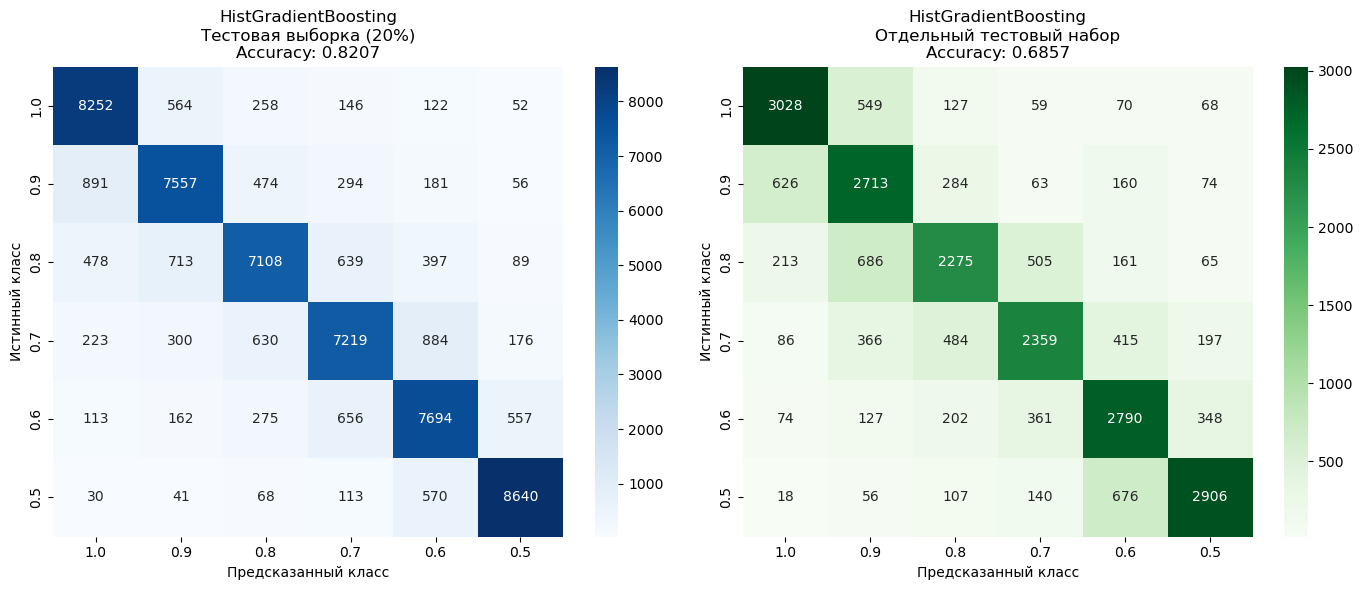

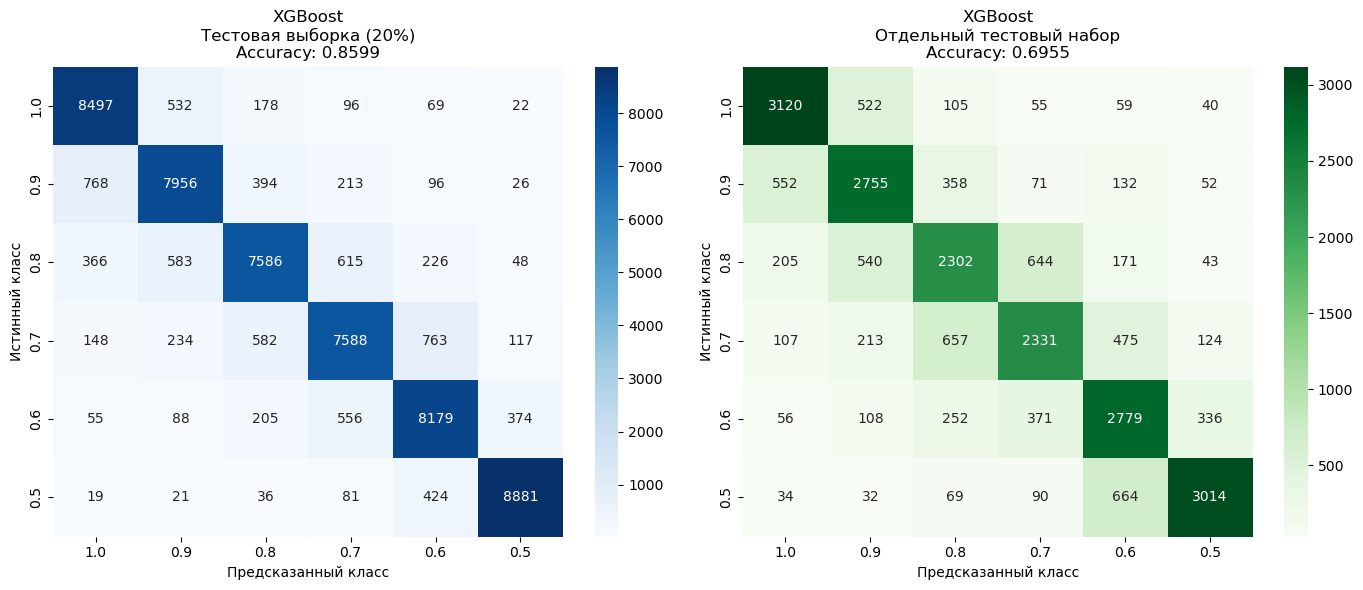

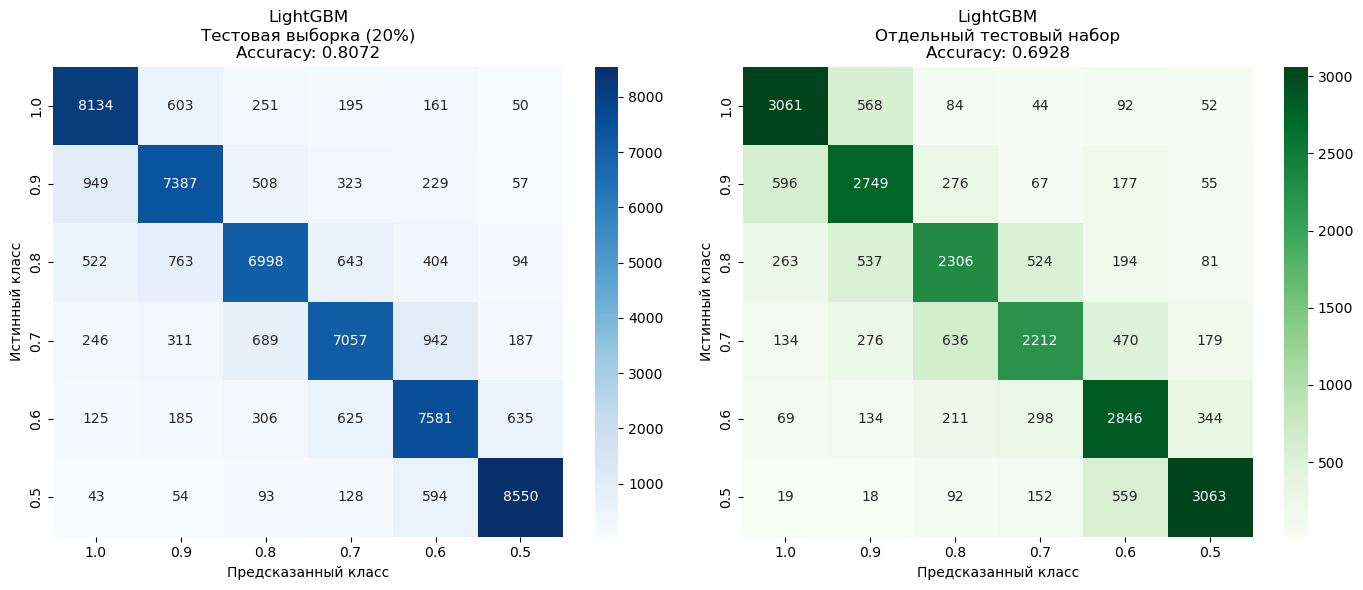


Сводная таблица результатов:
              Модель  Accuracy (20% тест)  Accuracy (отдельный тест)
HistGradientBoosting             0.820706                   0.685681
             XGBoost             0.859860                   0.695494
            LightGBM             0.807230                   0.692764

Результаты сохранены в 'model_comparison.csv'


In [29]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Загрузка данных
with open("DATA/real_time/selected_features.json", "r") as f:
    features = json.load(f)

features_df = pd.read_csv("DATA/features/MATLAB_features_ws64_overlap75.csv")
test_features_df = pd.read_csv("DATA/features_test_flight/MATLAB_TEST_features_ws64_overlap75.csv")

X = features_df.drop(columns=["Класс"])
y = features_df["Класс"].values

separate_X_test = test_features_df.drop(columns=["Класс"])
separate_y_test = test_features_df["Класс"].values

# Преобразование y
class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y), reverse=True))}
y = np.array([class_mapping[val] for val in y])
separate_y_test = np.array([class_mapping[val] for val in separate_y_test])

new_X = X[features].to_numpy(dtype=np.float32)
separate_X_test = separate_X_test[features].to_numpy(dtype=np.float32)

X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, stratify=y, random_state=42)

# Создание моделей
models = {
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, device="cuda", tree_method="hist", n_jobs=-1),
    'LightGBM': LGBMClassifier(verbose=-1, random_state=42)
}

# Словарь для хранения всех предсказаний и метрик
results = {}

# Обучение моделей и получение предсказаний
for name, model in models.items():
    print(f"\nОбучение модели: {name}")
    
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказания для тестовой выборки (20%)
    y_pred_test = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    
    # Предсказания для отдельного тестового набора
    y_pred_separate = model.predict(separate_X_test)
    acc_separate = accuracy_score(separate_y_test, y_pred_separate)
    
    # Сохранение результатов
    results[name] = {
        'y_test': y_test,
        'y_pred_test': y_pred_test,
        'acc_test': acc_test,
        'y_separate_test': separate_y_test,
        'y_pred_separate': y_pred_separate,
        'acc_separate': acc_separate
    }
    
    print(f"  Accuracy (20% тест): {acc_test:.4f}")
    print(f"  Accuracy (отдельный тест): {acc_separate:.4f}")

# Создание обратного маппинга для подписей классов
inverse_class_mapping = {v: k for k, v in class_mapping.items()}
class_labels = [inverse_class_mapping[i] for i in sorted(inverse_class_mapping.keys())]

# Построение матриц ошибок для каждой модели
for name, res in results.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Матрица для тестовой выборки (20%)
    cm_test = confusion_matrix(res['y_test'], res['y_pred_test'])
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
    axes[0].set_title(f'{name}\nТестовая выборка (20%)\nAccuracy: {res["acc_test"]:.4f}')
    axes[0].set_xlabel('Предсказанный класс')
    axes[0].set_ylabel('Истинный класс')
    
    # Матрица для отдельного тестового набора
    cm_separate = confusion_matrix(res['y_separate_test'], res['y_pred_separate'])
    sns.heatmap(cm_separate, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
    axes[1].set_title(f'{name}\nОтдельный тестовый набор\nAccuracy: {res["acc_separate"]:.4f}')
    axes[1].set_xlabel('Предсказанный класс')
    axes[1].set_ylabel('Истинный класс')
    
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "="*50)
print("Сводная таблица результатов:")
print("="*50)
comparison_df = pd.DataFrame({
    'Модель': list(results.keys()),
    'Accuracy (20% тест)': [res['acc_test'] for res in results.values()],
    'Accuracy (отдельный тест)': [res['acc_separate'] for res in results.values()]
})
print(comparison_df.to_string(index=False))

# Сохранение результатов в CSV
comparison_df.to_csv('model_comparison.csv', index=False)
print("\nРезультаты сохранены в 'model_comparison.csv'")


Обучение модели: HistGradientBoosting
  Accuracy (20% тест): 0.8827
  Accuracy (отдельный тест): 0.7987

Обучение модели: XGBoost
  Accuracy (20% тест): 0.9080
  Accuracy (отдельный тест): 0.8088

Обучение модели: LightGBM
  Accuracy (20% тест): 0.8738
  Accuracy (отдельный тест): 0.7975


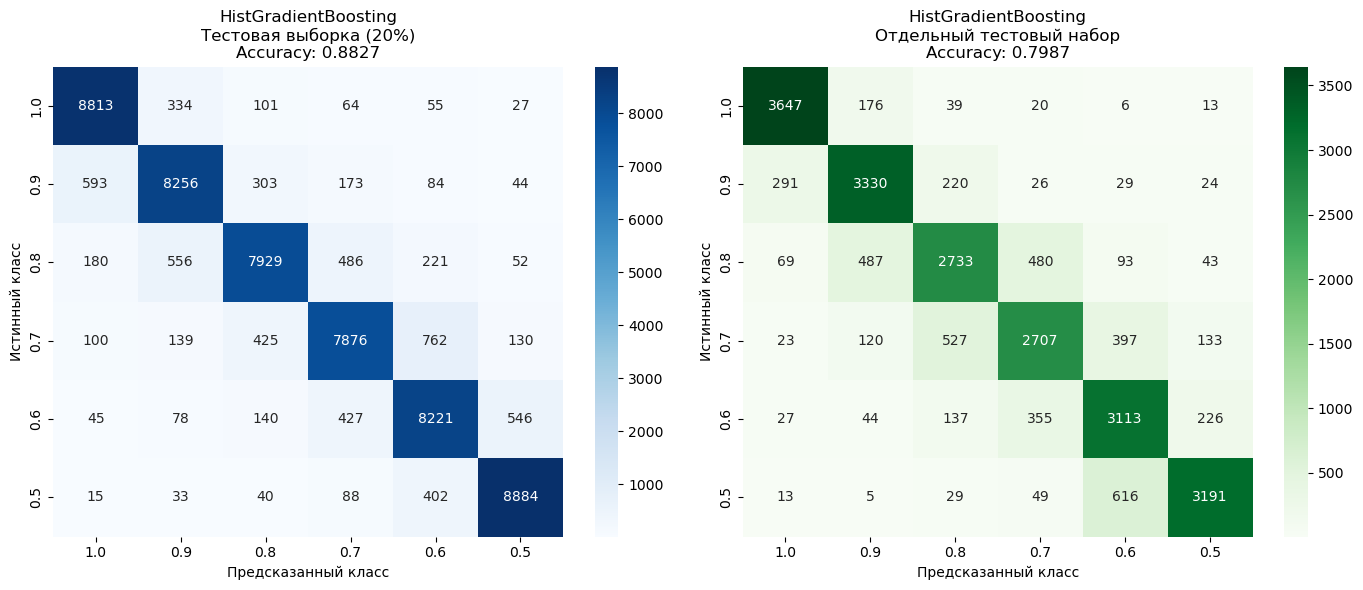

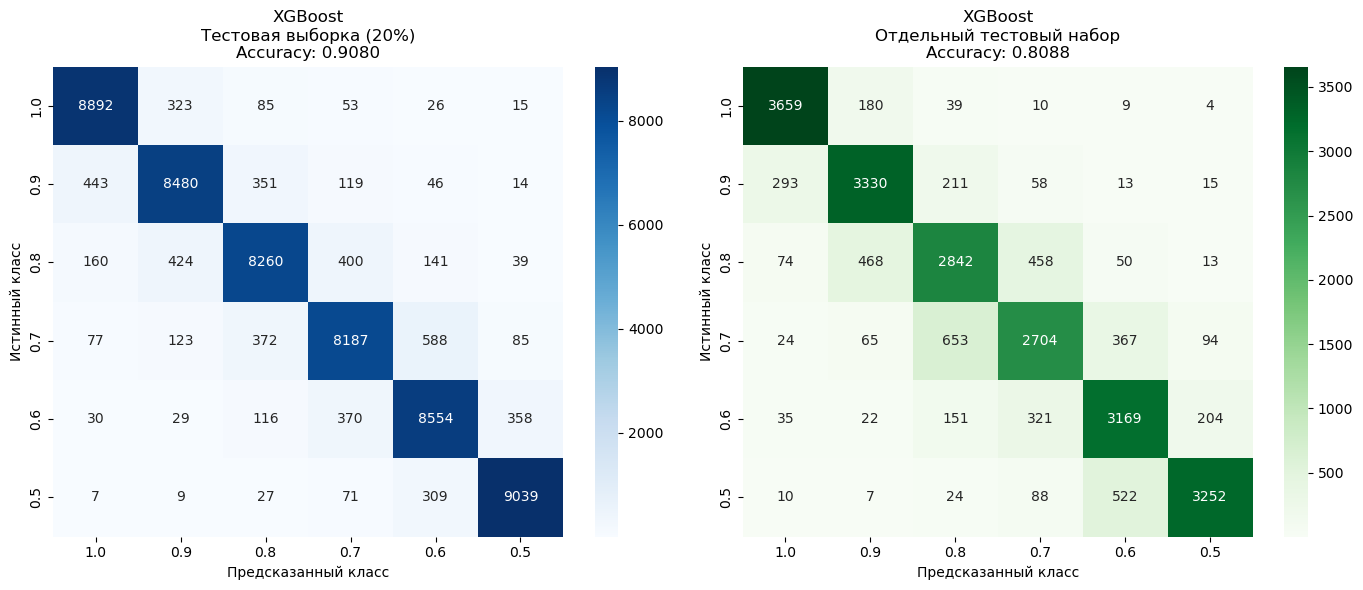

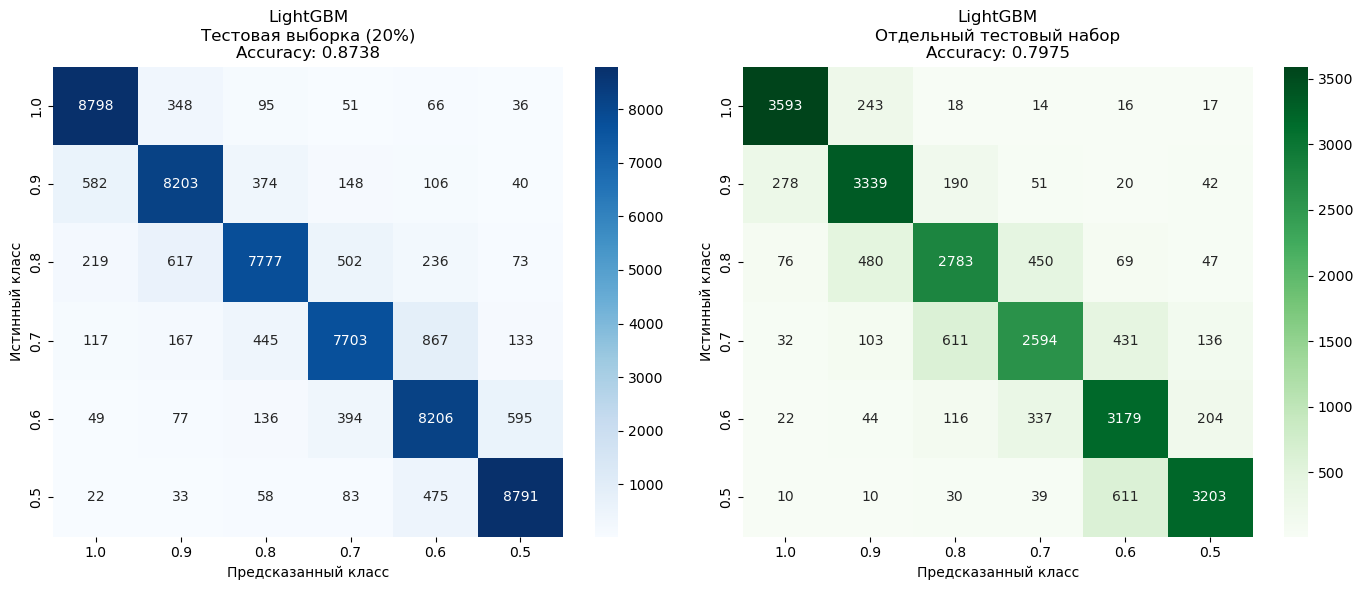


Сводная таблица результатов:
              Модель  Accuracy (20% тест)  Accuracy (отдельный тест)
HistGradientBoosting             0.882678                   0.798746
             XGBoost             0.907986                   0.808772
            LightGBM             0.873830                   0.797466

Результаты сохранены в 'model_comparison.csv'


In [30]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Загрузка данных
with open("DATA/real_time/selected_features.json", "r") as f:
    features = json.load(f)

features_df = pd.read_csv("DATA/features/MATLAB_features_ws64_overlap75.csv")
test_features_df = pd.read_csv("DATA/features_test_flight/MATLAB_TEST_features_ws64_overlap75.csv")

X = features_df.drop(columns=["Класс"])
y = features_df["Класс"].values

separate_X_test = test_features_df.drop(columns=["Класс"])
separate_y_test = test_features_df["Класс"].values

# Преобразование y
class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y), reverse=True))}
y = np.array([class_mapping[val] for val in y])
separate_y_test = np.array([class_mapping[val] for val in separate_y_test])

new_X = X.to_numpy(dtype=np.float32)
separate_X_test = separate_X_test.to_numpy(dtype=np.float32)

X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, stratify=y, random_state=42)

# Создание моделей
models = {
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, device="cuda", tree_method="hist", n_jobs=-1),
    'LightGBM': LGBMClassifier(verbose=-1, random_state=42)
}

# Словарь для хранения всех предсказаний и метрик
results = {}

# Обучение моделей и получение предсказаний
for name, model in models.items():
    print(f"\nОбучение модели: {name}")
    
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказания для тестовой выборки (20%)
    y_pred_test = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    
    # Предсказания для отдельного тестового набора
    y_pred_separate = model.predict(separate_X_test)
    acc_separate = accuracy_score(separate_y_test, y_pred_separate)
    
    # Сохранение результатов
    results[name] = {
        'y_test': y_test,
        'y_pred_test': y_pred_test,
        'acc_test': acc_test,
        'y_separate_test': separate_y_test,
        'y_pred_separate': y_pred_separate,
        'acc_separate': acc_separate
    }
    
    print(f"  Accuracy (20% тест): {acc_test:.4f}")
    print(f"  Accuracy (отдельный тест): {acc_separate:.4f}")

# Создание обратного маппинга для подписей классов
inverse_class_mapping = {v: k for k, v in class_mapping.items()}
class_labels = [inverse_class_mapping[i] for i in sorted(inverse_class_mapping.keys())]

# Построение матриц ошибок для каждой модели
for name, res in results.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Матрица для тестовой выборки (20%)
    cm_test = confusion_matrix(res['y_test'], res['y_pred_test'])
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
    axes[0].set_title(f'{name}\nТестовая выборка (20%)\nAccuracy: {res["acc_test"]:.4f}')
    axes[0].set_xlabel('Предсказанный класс')
    axes[0].set_ylabel('Истинный класс')
    
    # Матрица для отдельного тестового набора
    cm_separate = confusion_matrix(res['y_separate_test'], res['y_pred_separate'])
    sns.heatmap(cm_separate, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
    axes[1].set_title(f'{name}\nОтдельный тестовый набор\nAccuracy: {res["acc_separate"]:.4f}')
    axes[1].set_xlabel('Предсказанный класс')
    axes[1].set_ylabel('Истинный класс')
    
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "="*50)
print("Сводная таблица результатов:")
print("="*50)
comparison_df = pd.DataFrame({
    'Модель': list(results.keys()),
    'Accuracy (20% тест)': [res['acc_test'] for res in results.values()],
    'Accuracy (отдельный тест)': [res['acc_separate'] for res in results.values()]
})
print(comparison_df.to_string(index=False))

# Сохранение результатов в CSV
comparison_df.to_csv('model_comparison.csv', index=False)
print("\nРезультаты сохранены в 'model_comparison.csv'")

**Для дальнейшего использования выбрана модель LightGBM**

## Подбор гиперпараметров выбранной модели

In [11]:
num_of_features = 50

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", "r") as f:
    file = json.load(f)
    
features = file["optimal_features"][:num_of_features]
features_df = pd.read_csv("DATA/features/REAL_features_ws32_overlap75.csv")

X = features_df[features].to_numpy(dtype=np.float32)
y = features_df["Класс"].values

lgb_model = LGBMClassifier(
    force_col_wise=True,
    verbose=-1,
    n_jobs=1,
    random_state=42
)

param_grid = {
    "num_leaves": [15, 31, 63], 
    "max_depth": [3, 6, 9, -1],
    "n_estimators": [100, 300, 500]
}

grid_search = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры для LightGBM:", grid_search.best_params_)
print("Лучшая точность на CV:", grid_search.best_score_)

best_lgb_model = grid_search.best_estimator_
y_pred = best_lgb_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("Точность на тесте:", test_acc)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры для LightGBM: {'max_depth': -1, 'n_estimators': 500, 'num_leaves': 15}
Лучшая точность на CV: 0.968146029628292
Точность на тесте: 0.9715544871794872


## Итоговое обучение и сохранение модели

In [16]:
num_of_features = 50

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", "r") as f:
    selected_features = json.load(f)["optimal_features"][:num_of_features]
    
features_df = pd.read_csv("DATA/features/REAL_features_ws32_overlap96.875.csv")

X = features_df[selected_features].to_numpy(dtype=np.float32)
y = features_df["Класс"].to_numpy()

lgb_model = LGBMClassifier(
    verbose=-1,
    n_jobs=-1,
    random_state=42
)

lgb_model.fit(X, y)

# Сохраняем модель
with open("DATA/real_time/lgb_final_model.pkl", "wb") as f:
    pickle.dump(lgb_model, f)

# Сохраняем список признаков 
with open("DATA/real_time/selected_50_features.json", "w") as f:
    json.dump(selected_features, f)
